<a href="https://colab.research.google.com/github/IT22283344/DL_Assignment/blob/piuminda/resnet50_waste_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install tensorflow keras numpy pandas matplotlib seaborn scikit-learn opencv-python

In [5]:
!pip install kaggle

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import cv2
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
from google.colab import files
files.upload()  # upload kaggle.json


Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"enjoyfree","key":"ec656a13e6ce47db21def0ce4e767599"}'}

In [9]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [10]:
!kaggle datasets download -d techsash/waste-classification-data -p "/content/drive/MyDrive/4thyear/DL/assignment"

Dataset URL: https://www.kaggle.com/datasets/techsash/waste-classification-data
License(s): CC-BY-SA-4.0
waste-classification-data.zip: Skipping, found more recently modified local copy (use --force to force download)


In [11]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/4thyear/DL/assignment/waste-classification-data.zip"
extract_path = "/content/drive/MyDrive/4thyear/DL/assignment/waste-classification-data"


In [12]:
# Unzip only if not already extracted
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("✅ Dataset unzipped successfully.")
else:
    print("✅ Dataset already extracted.")

✅ Dataset already extracted.


In [13]:
dataset_path = "/content/drive/MyDrive/4thyear/DL/assignment/waste-classification-data/DATASET"

In [14]:
train_path = os.path.join(dataset_path, "TRAIN")
test_path = os.path.join(dataset_path, "TEST")

print("Dataset Base Path:", dataset_path)
print("Train Folder:", train_path)
print("Test Folder:", test_path)


Dataset Base Path: /content/drive/MyDrive/4thyear/DL/assignment/waste-classification-data/DATASET
Train Folder: /content/drive/MyDrive/4thyear/DL/assignment/waste-classification-data/DATASET/TRAIN
Test Folder: /content/drive/MyDrive/4thyear/DL/assignment/waste-classification-data/DATASET/TEST


In [15]:
def explore_dataset(path):
    print("\n📂 Dataset Structure:")
    for root, dirs, files in os.walk(path):
        level = root.replace(path, '').count(os.sep)
        indent = ' ' * 2 * level
        print(f"{indent}{os.path.basename(root)}/")
        subindent = ' ' * 2 * (level + 1)
        for file in files[:5]:  # Show first 5 files only
            print(f"{subindent}{file}")
        if len(files) > 5:
            print(f"{subindent}... and {len(files) - 5} more files")

explore_dataset(dataset_path)


📂 Dataset Structure:
DATASET/
  TEST/
    O/
      O_12568.jpg
      O_12569.jpg
      O_12570.jpg
      O_12571.jpg
      O_12572.jpg
      ... and 1396 more files
    R/
      R_10000.jpg
      R_10001.jpg
      R_10002.jpg
      R_10003.jpg
      R_10004.jpg
      ... and 1107 more files
  TRAIN/
    O/
      O_1.jpg
      O_10.jpg
      O_100.jpg
      O_1000.jpg
      O_10000.jpg
      ... and 12560 more files
    R/
      R_1.jpg
      R_10.jpg
      R_100.jpg
      R_1000.jpg
      R_1001.jpg
      ... and 9994 more files


In [16]:
# Count images per class
train_path = os.path.join(dataset_path, "TRAIN")
test_path = os.path.join(dataset_path, "TEST")

train_organic = len(os.listdir(os.path.join(train_path, "O")))
train_recyclable = len(os.listdir(os.path.join(train_path, "R")))
test_organic = len(os.listdir(os.path.join(test_path, "O")))
test_recyclable = len(os.listdir(os.path.join(test_path, "R")))

print(f"\nTraining Set:")
print(f"Organic: {train_organic} images")
print(f"Recyclable: {train_recyclable} images")
print(f"Total Training: {train_organic + train_recyclable} images")

print(f"\nTest Set:")
print(f"Organic: {test_organic} images")
print(f"Recyclable: {test_recyclable} images")
print(f"Total Test: {test_organic + test_recyclable} images")


Training Set:
Organic: 12565 images
Recyclable: 9999 images
Total Training: 22564 images

Test Set:
Organic: 1401 images
Recyclable: 1112 images
Total Test: 2513 images


Image dimensions analysis:
Height: min=123, max=282, mean=192.6
Width: min=150, max=410, mean=264.2
Channels: 3


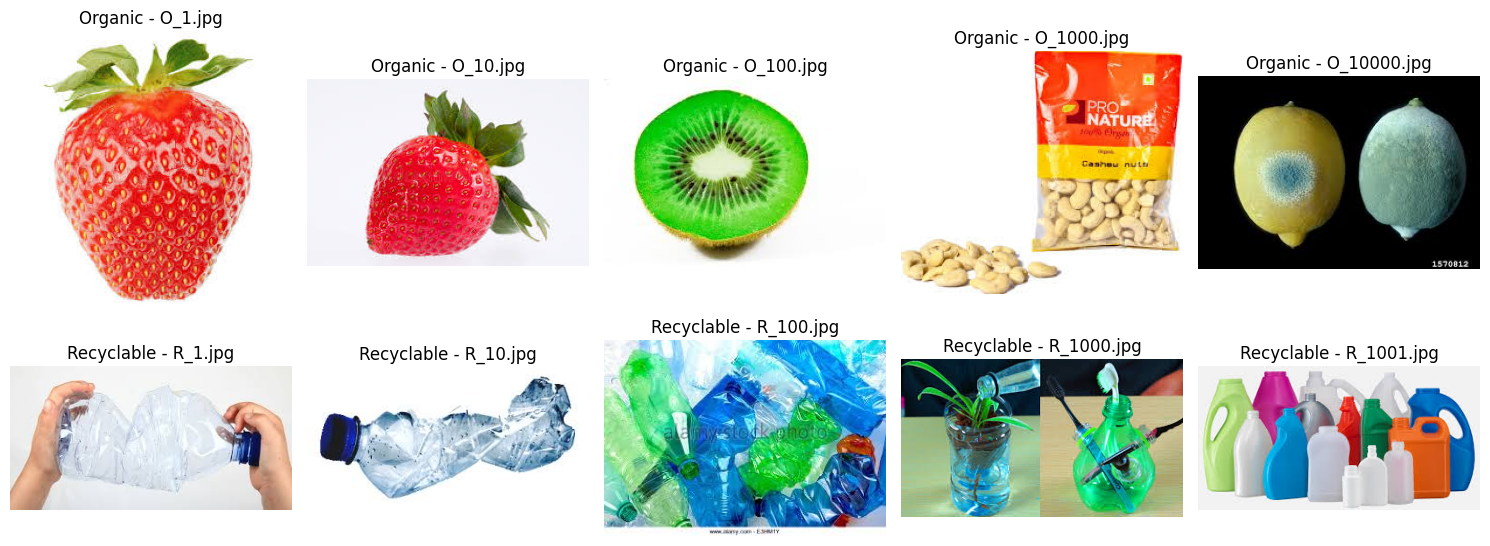

In [17]:
# Visualize sample images
def visualize_samples(path, class_names=['Organic', 'Recyclable']):
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))

    for i, class_name in enumerate(['O', 'R']):
        class_path = os.path.join(path, class_name)
        images = os.listdir(class_path)[:5]

        for j, img_name in enumerate(images):
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            axes[i, j].imshow(img)
            axes[i, j].set_title(f'{class_names[i]} - {img_name}')
            axes[i, j].axis('off')

    plt.tight_layout()
    plt.show()

# Analyze image dimensions
def analyze_image_dimensions(path):
    dimensions = []
    for class_name in ['O', 'R']:
        class_path = os.path.join(path, class_name)
        for img_name in os.listdir(class_path)[:100]:  # Sample 100 images
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                dimensions.append(img.shape)

    dimensions = np.array(dimensions)
    print(f"Image dimensions analysis:")
    print(f"Height: min={dimensions[:,0].min()}, max={dimensions[:,0].max()}, mean={dimensions[:,0].mean():.1f}")
    print(f"Width: min={dimensions[:,1].min()}, max={dimensions[:,1].max()}, mean={dimensions[:,1].mean():.1f}")
    print(f"Channels: {dimensions[:,2].max()}")

analyze_image_dimensions(train_path)
visualize_samples(train_path)